In [1]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))
# my utils
from utils import fa
from utils import modeling
from utils import preprocess_listings

# 标准版存档V0：
LABELS_EN=[
            'open to different cultures', 'cosmopolitan','international view', 'cultural exchange',
            'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life',
            'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction',
            'thoughtful service', 'attentive to needs', 'willing to help', 'responsive',
            'fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb'
        ]
DICT_FACTOR_ITEMS={"ouverture":['open to different cultures', 'cosmopolitan','international view', 'cultural exchange'],
                   "authenticité":['personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life'],
                   "sociabilité":['meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction'],
                   "auto_promotion":['thoughtful service', 'attentive to needs', 'willing to help', 'responsive'],
                   "exemplarité":['fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb']}


In [9]:
df_london=pd.read_csv("../data_processed_london\listings_london2406_bge_scores.csv")
df_paris=pd.read_csv("../data_processed_paris\listings_paris2406_bge_scores.csv")
df_all=pd.read_csv("../data_all\listings_paris_london2406.csv")

print(df_london.shape, df_paris.shape, df_all.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_15988\1873810557.py:2: DtypeWarning: Columns (77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df_paris=pd.read_csv("../data_processed_paris\listings_paris2406_bge_scores.csv")


(49856, 128) (62738, 128) (112594, 129)


C:\Users\yeliu\AppData\Local\Temp\ipykernel_15988\1873810557.py:3: DtypeWarning: Columns (68,77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv("../data_all\listings_paris_london2406.csv")


In [14]:
# filtered by booking_rate_l90d
print(df_paris[['booking_rate_l90d_previousQ',"booking_rate_l90d"]].isna().value_counts(dropna=False)/len(df_paris))
print(df_paris[["number_of_reviews_till_previousQ",'number_of_reviews_thisQ','number_of_reviews_till_nextQ',"number_of_reviews_nextQ"]].isna().value_counts(dropna=False)/len(df_paris))
print(df_paris[["availability_90_previousQ","availability_90"]].isna().value_counts(dropna=False)/len(df_paris))


booking_rate_l90d_previousQ  booking_rate_l90d
False                        False                0.565957
True                         False                0.434043
Name: count, dtype: float64
number_of_reviews_till_previousQ  number_of_reviews_thisQ  number_of_reviews_till_nextQ  number_of_reviews_nextQ
False                             False                    False                         False                      1.0
Name: count, dtype: float64
availability_90_previousQ  availability_90
False                      False              0.751889
True                       False              0.248111
Name: count, dtype: float64


In [35]:
print('PARIS'.center(100,'-'))
# print(df_paris.columns.to_list())
# print(df_paris.status.value_counts(dropna=False)/len(df_paris),'\n')
# df_paris['no_change']=df_paris.apply(lambda row : 1 if row['status']=="old_host" and row["sp_changed"]==0 else 0, axis=1)
print(df_paris[['status','status_changed','sp_changed','old_host_sp_changed','is_changed']].value_counts(dropna=False)/len(df_paris))
## 不能认为新进入导致的sp_changed==1一定受到jo影响
# sp_changed/old_host_sp_changed二选一！


#****
print('LONDON'.center(100,'-'))
# print(df_london.columns.to_list())
# print(df_london.status.value_counts(dropna=False)/len(df_london),'\n')
# df_london['no_change']=df_london.apply(lambda row : 1 if row['status']=="old_host" and row["sp_changed"]==0 else 0, axis=1)
print(df_london[['status','status_changed','sp_changed','old_host_sp_changed',"is_changed"]].value_counts(dropna=False)/len(df_london))


-----------------------------------------------PARIS------------------------------------------------
status         status_changed  sp_changed  old_host_sp_changed  is_changed
old_host       0               0           0                    0             0.536214
reopen_host    1               0           0                    1             0.177357
reactive_host  1               1           0                    1             0.143438
old_host       0               1           1                    1             0.100067
new_host       1               1           0                    1             0.034349
reopen_host    1               1           0                    1             0.008575
Name: count, dtype: float64
-----------------------------------------------LONDON-----------------------------------------------
status         status_changed  sp_changed  old_host_sp_changed  is_changed
old_host       0               0           0                    0             0.703967
           

## desc

In [ ]:
importlib.reload(preprocess_listings)
from utils.preprocess_listings import group_mean_table_ttest
OUTPUT_FOLDER_DESC=Path("../output_desc")
os.makedirs(OUTPUT_FOLDER_DESC, exist_ok=True)

cols_to_check=[
    # "host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating",'number_of_reviews',
    "years_since_host", "professional_host",#'calculated_host_listings_count',
    # "lang", "len",
    "price", "availability_30","availability_90", "room_type", "instant_bookable",
    "number_of_reviews_thisQ", "number_of_reviews_nextQ",
    "booking_rate_l90d_previousQ", "booking_rate_l90d",'is_changed', 'city'
]   
tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]

group_mean_table_ttest(df=df_paris, #*
            cols_to_check=cols_to_check+tactics_vars, 
            group_col='status_changed', #*
            save=False, output_folder=OUTPUT_FOLDER_DESC, filename_noext=None)


#非常整齐的personal tactics 集中在为未改变的老房东？

[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 62738 lines.

[WARNING]2 missing cols in df_input :
 number_of_reviews; city

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 room_type; instant_bookable



d:\miniconda3\envs\airbnb_env\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
d:\miniconda3\envs\airbnb_env\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


status_changed,0,1,ttest_p,significance
proportion,0.636281,0.363719,NaN,NaN
review_scores_rating,4.751397,4.806522,0.0,***
years_since_host,6.867632,6.782374,0.006845,**
professional_host,0.457526,0.146106,0.0,***
price,268.566547,309.246812,0.0,***
availability_30,13.200731,7.493361,0.0,***
availability_90,53.647085,43.408826,0.0,***
number_of_reviews_thisQ,3.460257,2.717911,0.0,***
number_of_reviews_nextQ,2.734212,1.588106,0.0,***
booking_rate_l90d_previousQ,0.164557,NaN,NaN,


In [61]:

group_mean_table_ttest(df=df_all, #*
            cols_to_check=cols_to_check+tactics_vars, 
            group_col='is_changed', #*
            save=False, output_folder=OUTPUT_FOLDER_DESC, filename_noext=None)
## changed host prefer markting ! 

[CHECK] remove group_col 'is_changed' from vars
[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 112594 lines.

[WARNING]1 missing cols in df_input :
 number_of_reviews

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 room_type; instant_bookable; city



is_changed,0,1,ttest_p,significance
proportion,0.610494,0.389506,NaN,NaN
review_scores_rating,4.741307,4.779337,0.0,***
years_since_host,6.848133,6.316969,0.0,***
professional_host,0.508991,0.400059,0.0,***
price,235.293084,276.467097,0.0,***
availability_30,12.715994,9.237003,0.0,***
availability_90,52.498793,46.284636,0.0,***
number_of_reviews_thisQ,3.025968,5.240036,0.0,***
number_of_reviews_nextQ,2.823475,2.445002,0.0,***
booking_rate_l90d_previousQ,0.130936,0.14482,0.000663,***


In [ ]:
group_mean_table_ttest(df=df_paris, 
            cols_to_check=cols_to_check+tactics_vars, 
            group_col='status_changed',
            save=False, output_folder=OUTPUT_FOLDER_DESC, filename_noext=None)
# status changed==1 act like superhost?? only auto-promotion is negative!

[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 62738 lines.

[WARNING]2 missing cols in df_input :
 number_of_reviews; city

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 room_type; instant_bookable



d:\miniconda3\envs\airbnb_env\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
d:\miniconda3\envs\airbnb_env\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


status_changed,0,1,ttest_p,significance
proportion,0.636281,0.363719,NaN,NaN
review_scores_rating,4.751397,4.806522,0.0,***
years_since_host,6.867632,6.782374,0.006845,**
professional_host,0.457526,0.146106,0.0,***
price,268.566547,309.246812,0.0,***
availability_30,13.200731,7.493361,0.0,***
availability_90,53.647085,43.408826,0.0,***
number_of_reviews_thisQ,3.460257,2.717911,0.0,***
number_of_reviews_nextQ,2.734212,1.588106,0.0,***
booking_rate_l90d_previousQ,0.164557,NaN,NaN,


In [ ]:
group_mean_table_ttest(df=df_paris, 
            cols_to_check=cols_to_check+tactics_vars, 
            group_col='sp_changed',
            save=False, output_folder=OUTPUT_FOLDER_DESC, filename_noext=None)
## sp_changed==1 LIKE MARKETING tactics

[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 62738 lines.

[WARNING]2 missing cols in df_input :
 number_of_reviews; city

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 room_type; instant_bookable



d:\miniconda3\envs\airbnb_env\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


sp_changed,0,1,ttest_p,significance
proportion,0.713571,0.286429,NaN,NaN
review_scores_rating,4.767013,4.782494,0.0,***
years_since_host,7.191387,5.95281,0.0,***
professional_host,0.345157,0.342014,0.453432,
price,280.933055,289.415693,0.203327,
availability_30,10.968326,11.514802,0.0,***
availability_90,48.831018,52.64424,0.0,***
number_of_reviews_thisQ,2.613608,4.626822,0.0,***
number_of_reviews_nextQ,2.350295,2.235281,0.000643,***
booking_rate_l90d_previousQ,0.164845,0.159374,0.374961,


In [59]:
group_mean_table_ttest(df=df_paris, 
            cols_to_check=cols_to_check+tactics_vars, 
            group_col='old_host_sp_changed',
            save=False, output_folder=OUTPUT_FOLDER_DESC, filename_noext=None)

[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 62738 lines.

[WARNING]2 missing cols in df_input :
 number_of_reviews; city

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 room_type; instant_bookable



d:\miniconda3\envs\airbnb_env\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


old_host_sp_changed,0,1,ttest_p,significance
proportion,0.899933,0.100067,NaN,NaN
review_scores_rating,4.77627,4.728076,0.0,***
years_since_host,6.955349,5.768875,0.0,***
professional_host,0.293376,0.801848,0.0,***
price,276.936185,341.158649,0.000057,***
availability_30,10.891304,13.225231,0.0,***
availability_90,49.246086,56.013061,0.0,***
number_of_reviews_thisQ,3.025894,4.668366,0.0,***
number_of_reviews_nextQ,2.252993,2.896145,0.0,***
booking_rate_l90d_previousQ,0.164845,0.159374,0.374961,


In [36]:
group_mean_table_ttest(df=df_paris, 
            cols_to_check=cols_to_check+tactics_vars, 
            group_col='is_changed',
            save=False, output_folder=OUTPUT_FOLDER_DESC, filename_noext=None)

[CHECK] remove group_col 'is_changed' from vars
[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 62738 lines.

[WARNING]2 missing cols in df_input :
 number_of_reviews; city

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 room_type; instant_bookable



is_changed,0,1,ttest_p,significance
proportion,0.536214,0.463786,NaN,NaN
review_scores_rating,4.75575,4.789597,0.0,***
years_since_host,7.072679,6.563701,0.0,***
professional_host,0.39327,0.28759,0.0,***
price,255.019589,316.132144,0.0,***
availability_30,13.196159,8.730075,0.0,***
availability_90,53.205553,46.128329,0.0,***
number_of_reviews_thisQ,3.234803,3.138743,0.333688,
number_of_reviews_nextQ,2.703992,1.87033,0.0,***
booking_rate_l90d_previousQ,0.164845,0.159374,0.374961,


## tactics model

In [107]:
importlib.reload(modeling)
from utils.modeling import modeling_tactics

y_var="booking_rate_l90d" #"availability_90" #"price" 
x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    'status_changed', 'old_host_sp_changed',# "is_changed"
    'city',
    "lang", "len",
    "price", 
    "availability_90","room_type", "instant_bookable", #'is_within_1km',#"city"
]  
tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]



In [108]:

for tactic in tactics_vars:
    print(f"{tactic}".center(100, '-'))
    modeling_tactics(df_input=df_all,     
                x_vars=x_vars, 
                y_var=tactic, 
                key_vars=None, 
                group_col=None,
                to_fillna0=True)
    break 

---------------------------------------------ouverture----------------------------------------------

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:15, x_vars_ctrl:15
[CHECK] isna False in all 16 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  status_changed  old_host_sp_changed  city   lang   len    price  availability_90  room_type  instant_bookable  ouverture
False                   False                 False                 False             False              False              False           False                False  False  False  False  False            False      False             True         59889
                                                                                                                                                                                                                         

## booking mod
jo冲击下（city==paris）不同tactics对于预订率的是否变化？

### one city : paris

In [143]:
## X superhost

import os, sys, importlib, pathlib
import pandas as pd
sys.path.append(os.path.abspath(".."))
from utils import split_listings, preprocess_listings

importlib.reload(split_listings)
importlib.reload(preprocess_listings)
from utils.split_listings import split_change_stable
from utils.preprocess_listings import preprocess_host_variables, preprocess_obj_vars


# --------------------vars---------------------------- 
# y_var="booking_rate_l90d" #"availability_90" #"price" 
# x_vars=["host_identity_verified", "host_has_profile_pic",         
#     "review_scores_rating", #"has_rating", "number_of_reviews",
#     "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
#     # 'status_changed', 'old_host_sp_changed',# "is_changed"
#     "lang", "len",
#     "price", 
#     "availability_30","room_type", "instant_bookable", #'is_within_1km',#"city"
# ]  
# tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]


# --------------------------traitement--------------------
df_paris2312=pd.read_csv("../data_all\listings_paris2312_scores.csv")

# df_split=split_change_stable(path_Q1, path_Q2, year=2024, 
#                        threshold_text_sim=0.85, 
#                        save=True,
#                        output_folder="../data_processed_london",
#                        filename="listings_london2406_split.csv")

df_split=df_paris2312.copy()

path_Q3="../data_raw\listings_paris2403.csv"
dfQ3=pd.read_csv(path_Q3)
df_processed=preprocess_host_variables(df_split)
df_filtered=preprocess_obj_vars(df=df_processed, df_nextQ=dfQ3, proxy_vars=['price',"availability_30","availability_90"], 
                        get_booking_rate_l30d=True, filtrate_by_booking_rate_l30d=True,#无输入时默认不按照booking筛选 
                        get_booking_rate_l90d=False, filtrate_by_booking_rate_l90d=False,
                        obj_vars=["room_type", 'property_type',"minimum_nights","instant_bookable"], 
                        threshold_km=1, 
                        output_folder="../data_all", filename=f"listings_paris2312_filtered.csv")
print(len(df_filtered))
# display(df_paris2312.head())
# print(df_paris2312.columns.to_list())

# modeling_main(df_input=df_paris2312, 
#             x_vars=x_vars, 
#             y_var="booking_rate_l90d", 
#             key_vars=tactics_vars, 
#             group_col='host_is_superhost',#==stauts_changed+sp_changed
#             output_folder=None,
#             to_fillna0=True,
#             run_vif=False,
#             # save_models_summary=False,  
#             save_models_table=False,
#             save_plots=False,
#             ndigits=4
#         )

C:\Users\yeliu\AppData\Local\Temp\ipykernel_33416\1300240169.py:28: DtypeWarning: Columns (7,23,42,46,47,62) have mixed types. Specify dtype option on import or set low_memory=False.
  df_paris2312=pd.read_csv("../data_all\listings_paris2312_scores.csv")




******************************HOST VARS******************************
PROCESS PIPELINE :
- host_has_profile_pic : fillna('f') if not f/t
- host_identity_verified: fillna('f') if not f/t 
- host_is_sueprhost: check ONLY 't'/'f'; fillna('f')
- review_scores_rating: 24.0% NaN; fillna(mean), to numeric; ADD 'has_rating' 
- host_since: ADD 'years_since_host' :float, 0.5-1 year=>1， 0-0.5 year => 0 
- has_host_about: 'lang:en/fr/other_langs','len:int',
- host_response_time:41.0% NaN, fillna('no_response_time') 
- host_response_rate:41.0% NaN, ADD 'has_response_rate' :1/0， fillna(0)
- calculated_host_listings_count : ADD 'professional_host:1/0', count>1

[INFO] missing review scores are filled by mean :4.689369847503803

==========================HOST VARS================================
16 IMPO VARS:['host_picture_url', 'host_identity_verified', 'number_of_reviews', 'host_is_superhost', 'review_scores_rating', 'has_rating', 'host_since', 'years_since_host', 'host_about', 'lang', 'len', 'hos

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\preprocess_listings.py:421: RuntimeWarning: All-NaN axis encountered
  return np.nanmin(distances) if len(distances) > 0 else np.nan


is_within_1km
0    68370
1     5960
Name: count, dtype: int64
# -----------------------filter & desc-------------------------
[INFO] vars to dropna:is_within_1km; booking_rate_l30d; instant_bookable; property_type; number_of_reviews_l30d; availability_30; room_type; price; availability_90; minimum_nights
[CHECK] no filter on  'number_of_reviews_nextQ','availability_90','booking_rate_l90d'!
[INFO]0 nan dropped in is_within_1km
[INFO]36743 nan dropped in booking_rate_l30d
[INFO]0 nan dropped in instant_bookable
[INFO]0 nan dropped in property_type
[INFO]0 nan dropped in number_of_reviews_l30d
[INFO]0 nan dropped in availability_30
[INFO]1 nan dropped in room_type
[INFO]573 nan dropped in price
[INFO]0 nan dropped in minimum_nights

len BEFORE filtrage by is_within_1km; booking_rate_l30d; instant_bookable; property_type; number_of_reviews_l30d; availability_30; room_type; price; availability_90; minimum_nights: 74330
len AFTER: 37013


================= BALN PROCESSED VARIABLES ==========

In [2]:
df_paris2312=pd.read_csv("../data_all/listings_paris2312_filtered.csv")
print(len(df_paris2312))
print(df_paris2312.columns.to_list())

37013
['Unnamed: 0', 'id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availabi

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:12, x_vars_ctrl:12
[CHECK] isna False in all 13 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  lang   len    price  availability_30  room_type  instant_bookable  booking_rate_l30d
False                   False                 False                 False             False              False              False  False  False  False            False      False             False                37013
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_

,is_base,coef,se,t,pval,sig
f,True,0.000429,0.002289,0.187214,0.851494,
t,False,-0.010022,0.003574,-2.804208,0.005047,**


authenticité
x f/t


,is_base,coef,se,t,pval,sig
f,True,0.006953,0.002485,2.798183,0.005142,**
t,False,-0.003078,0.004084,-0.753756,0.451001,


sociabilité
x f/t


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_30+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_30+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


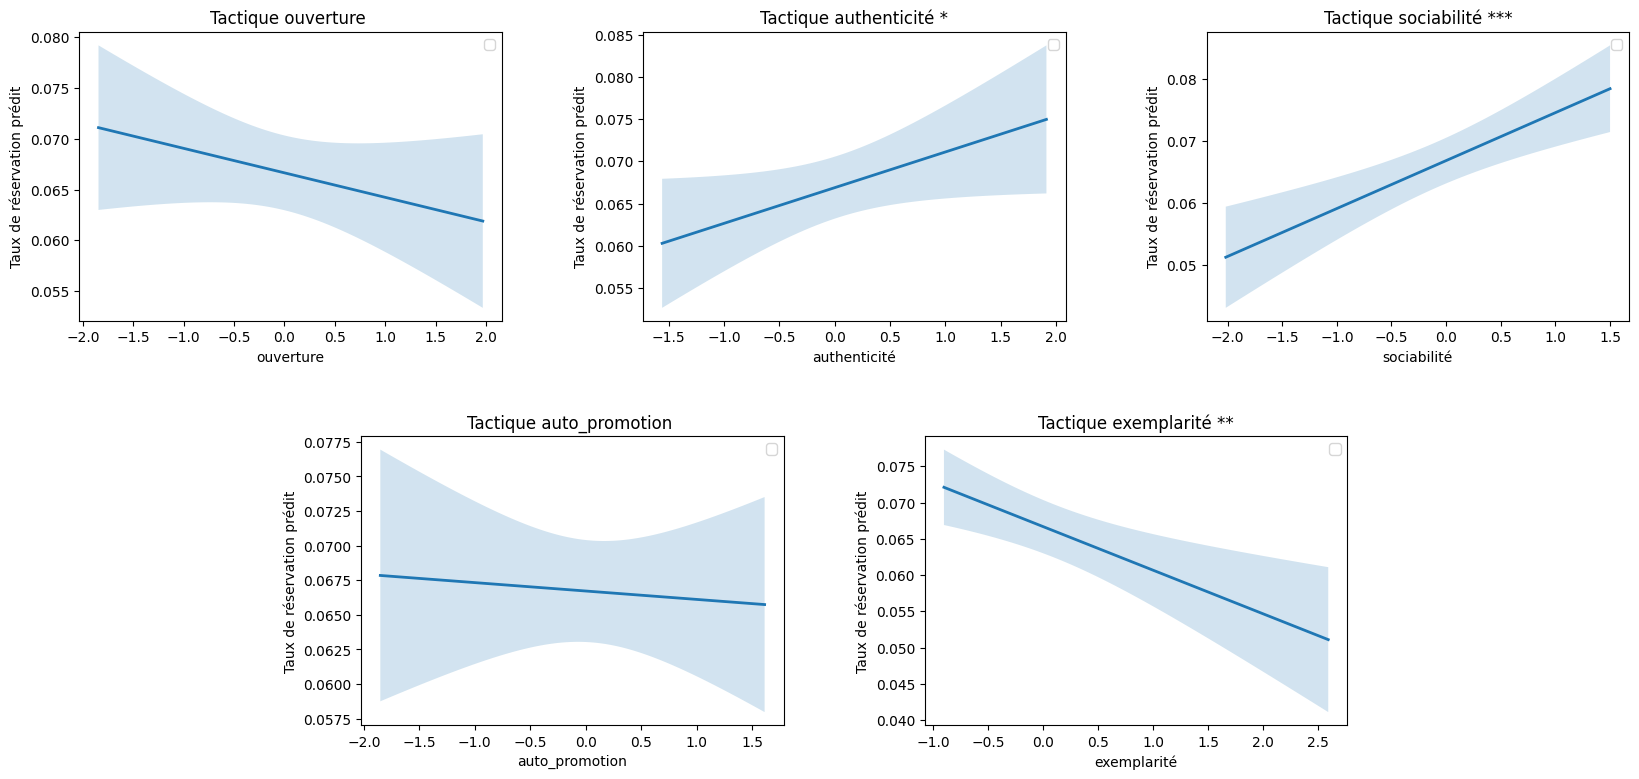

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_30+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_30+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_30+ C(host_is_s

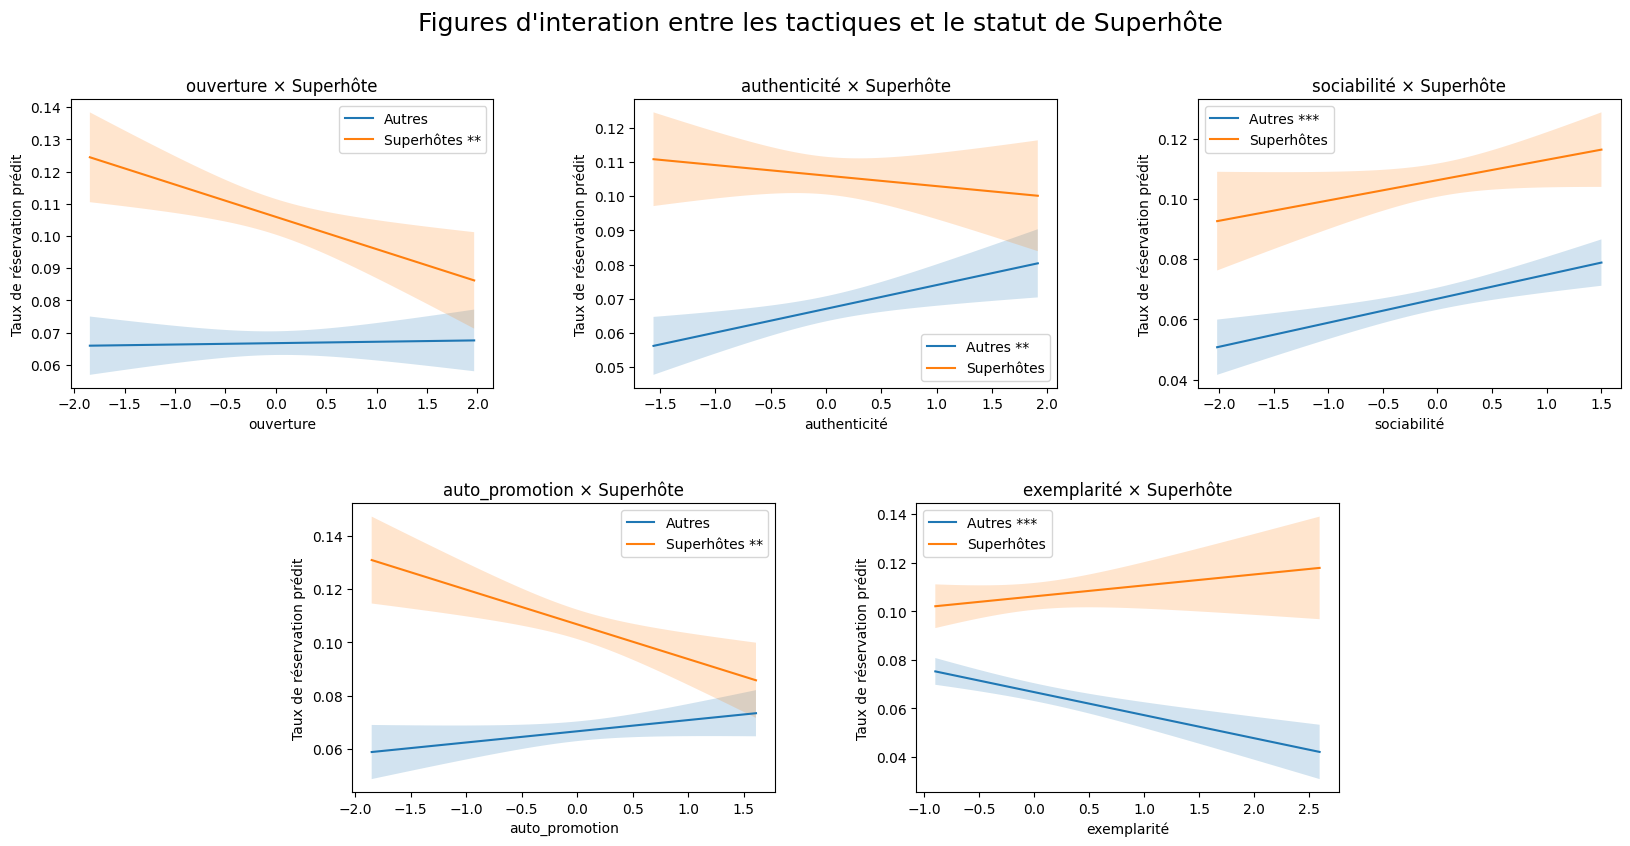

In [6]:
importlib.reload(modeling)
from utils.modeling import modeling_main,build_model
importlib.reload(modeling)
from utils.modeling import modeling_main, get_booking_rate_l30d

#-------------------------------vars------------------------------------

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "len",
    "price", 
    "availability_30",#*
    "room_type", "instant_bookable", #'is_within_1km',#"city"
]  
tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]


#-------------------------------output------------------------------------
# OUTPUT_FOLDER_MOD=Path("../output_mod_paris/booking90-status")
df_paris2312=pd.read_csv("../data_all/listings_paris2312_filtered.csv")

modeling_main(df_input=df_paris2312, 
            x_vars=x_vars, 
            y_var="booking_rate_l30d", 
            key_vars=tactics_vars, 
            group_col='host_is_superhost',#==stauts_changed+sp_changed
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

# is_changed 作为交互项没有显著性，说明不能只改变，需要进行特殊类型的改变？


# 除了autopromotion，superhost&autres之间没有显著差异

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================
[INFO] results saved to ..\output_mod_paris\booking90-status!


 ============================================basic model============================================= 

[NUMBER CHECK1] y_var:booking_rate_l90d, x_vars:14,
key_vars:No key vars, group_col:None
[CHECK] isna False in all 15 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  status_changed  old_host_sp_changed  lang   len    price  availability_90  room_type  instant_bookable  booking_rate_l90d
False                   False                 False                 False             False              False              False           False                False  False  False  False            False      False             Fa

,is_base,coef,se,t,pval,sig
0,True,-0.004488,0.001237,-3.62855,0.000285,***
1,True,-0.004488,0.001237,-3.62855,0.000285,***


authenticité
x 0/1


,is_base,coef,se,t,pval,sig
0,True,0.00255,0.001341,1.901737,0.05721,
1,True,0.00255,0.001341,1.901737,0.05721,


sociabilité
x 0/1


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:645: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + old_host_sp_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:645: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + old_host_sp_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:645: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  


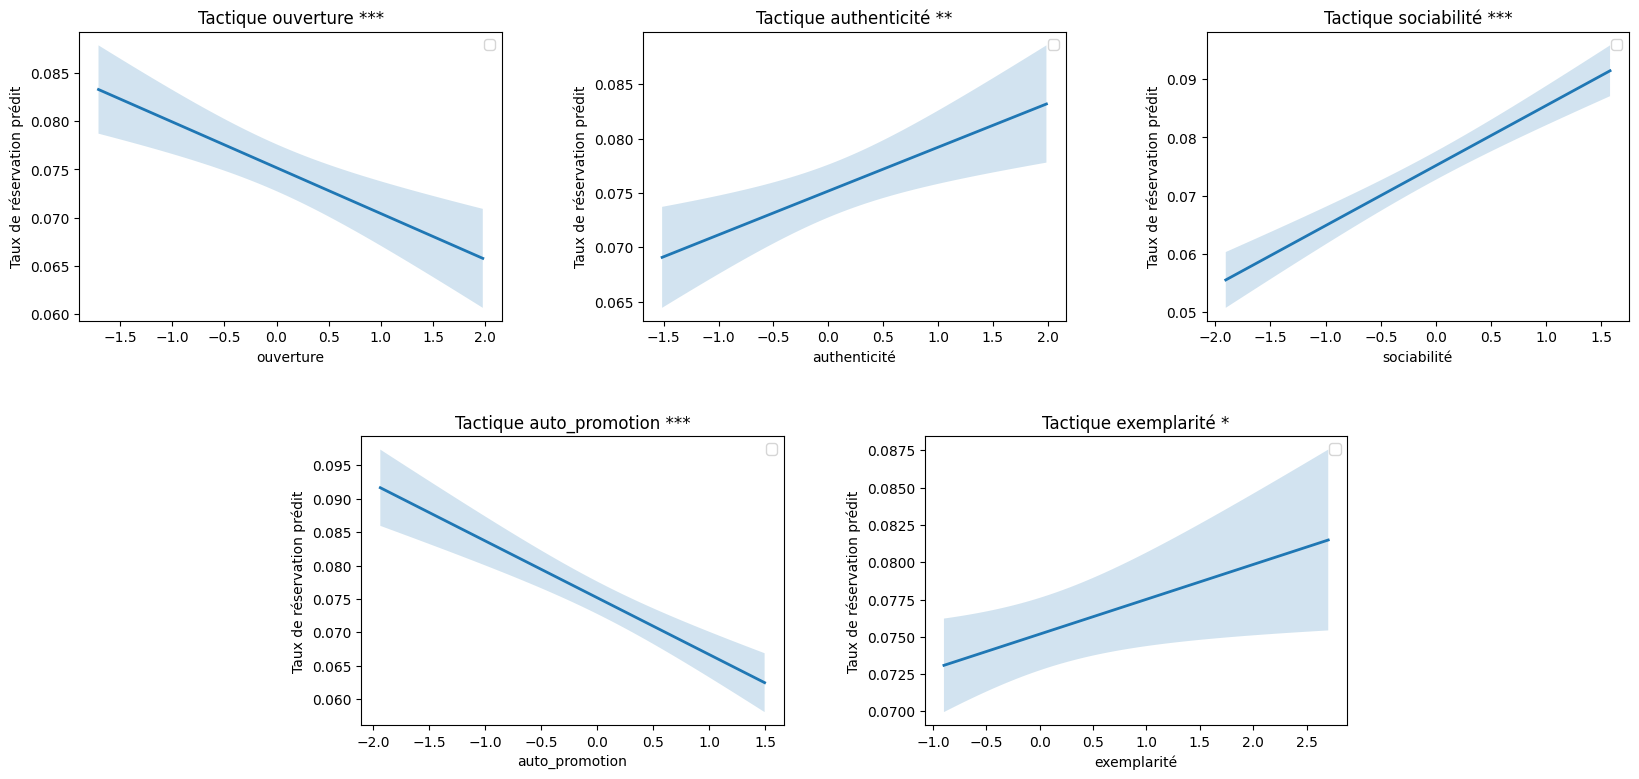

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ old_host_sp_changed * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ old_host_sp_changed * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + rev

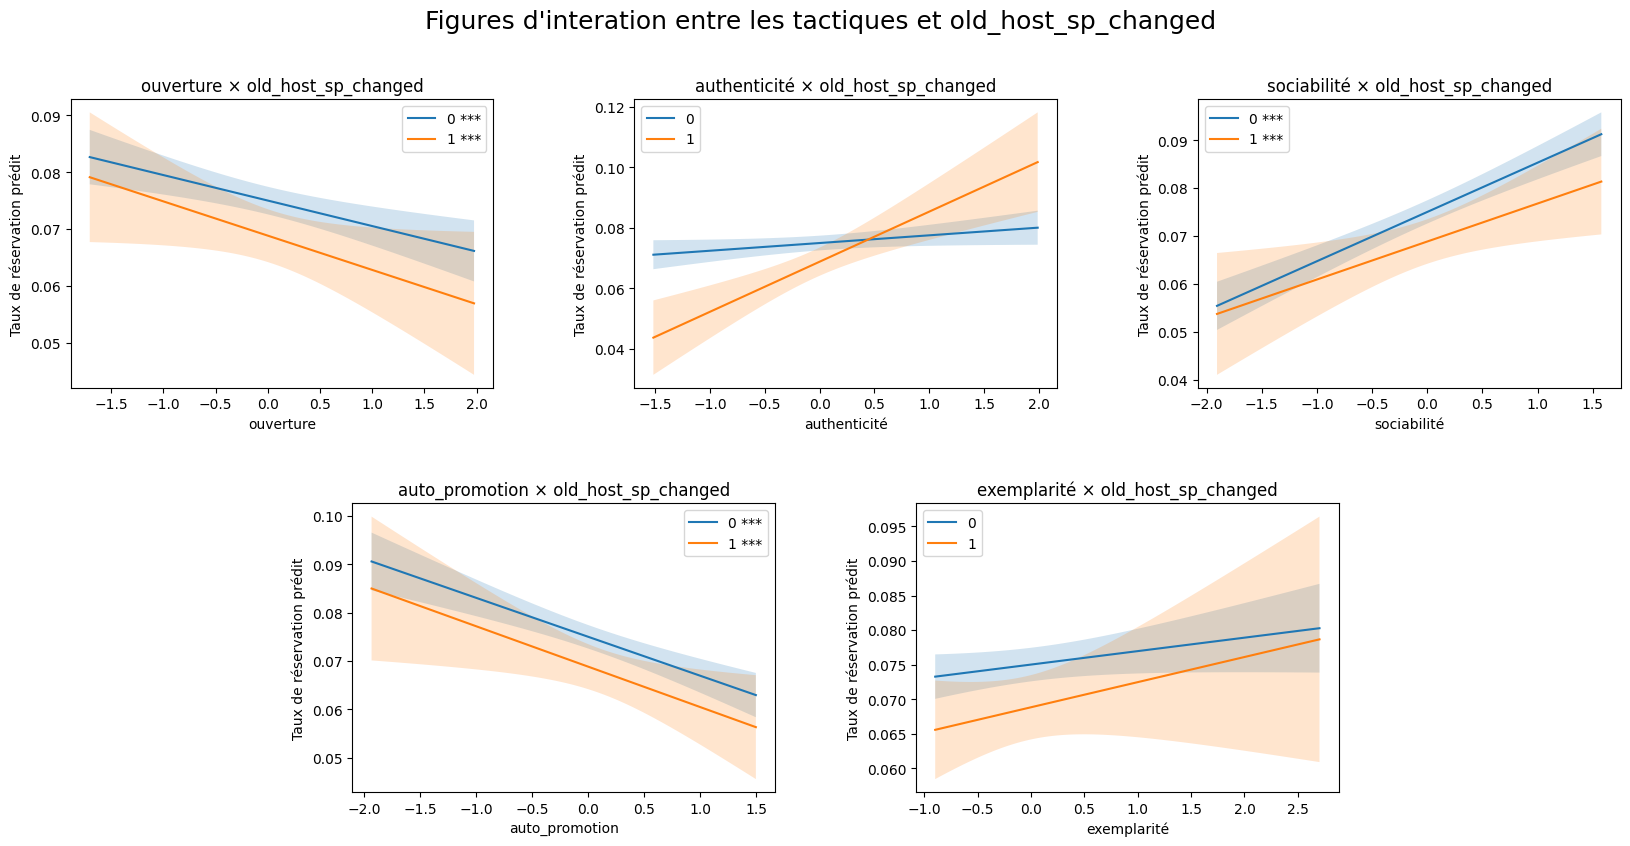

In [ ]:
modeling_main(df_input=df_paris, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col='old_host_sp_changed',
            output_folder=OUTPUT_FOLDER_MOD,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )
## status/sp_changed交互时，均只有authenticity有显著差异
##==> 是否改变影响不大？

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================
[INFO] results saved to ..\output_mod_paris\booking90-status!


 ============================================basic model============================================= 

[CHECK] isna False in all 13 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  sp_changed  lang   len    price  availability_90  room_type  instant_bookable  booking_rate_l90d
False                   False                 False                 False             False              False       False  False  False  False            False      False             False                49856
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instan

,is_base,coef,se,t,pval,sig
1,True,0.00203,0.001519,1.336268,0.181468,
0,True,0.00203,0.001519,1.336268,0.181468,


authenticité
x 1/0


,is_base,coef,se,t,pval,sig
1,True,0.006533,0.001689,3.868171,0.00011,***
0,True,0.006533,0.001689,3.868171,0.00011,***


sociabilité
x 1/0


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:590: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + sp_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:590: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + sp_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:590: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


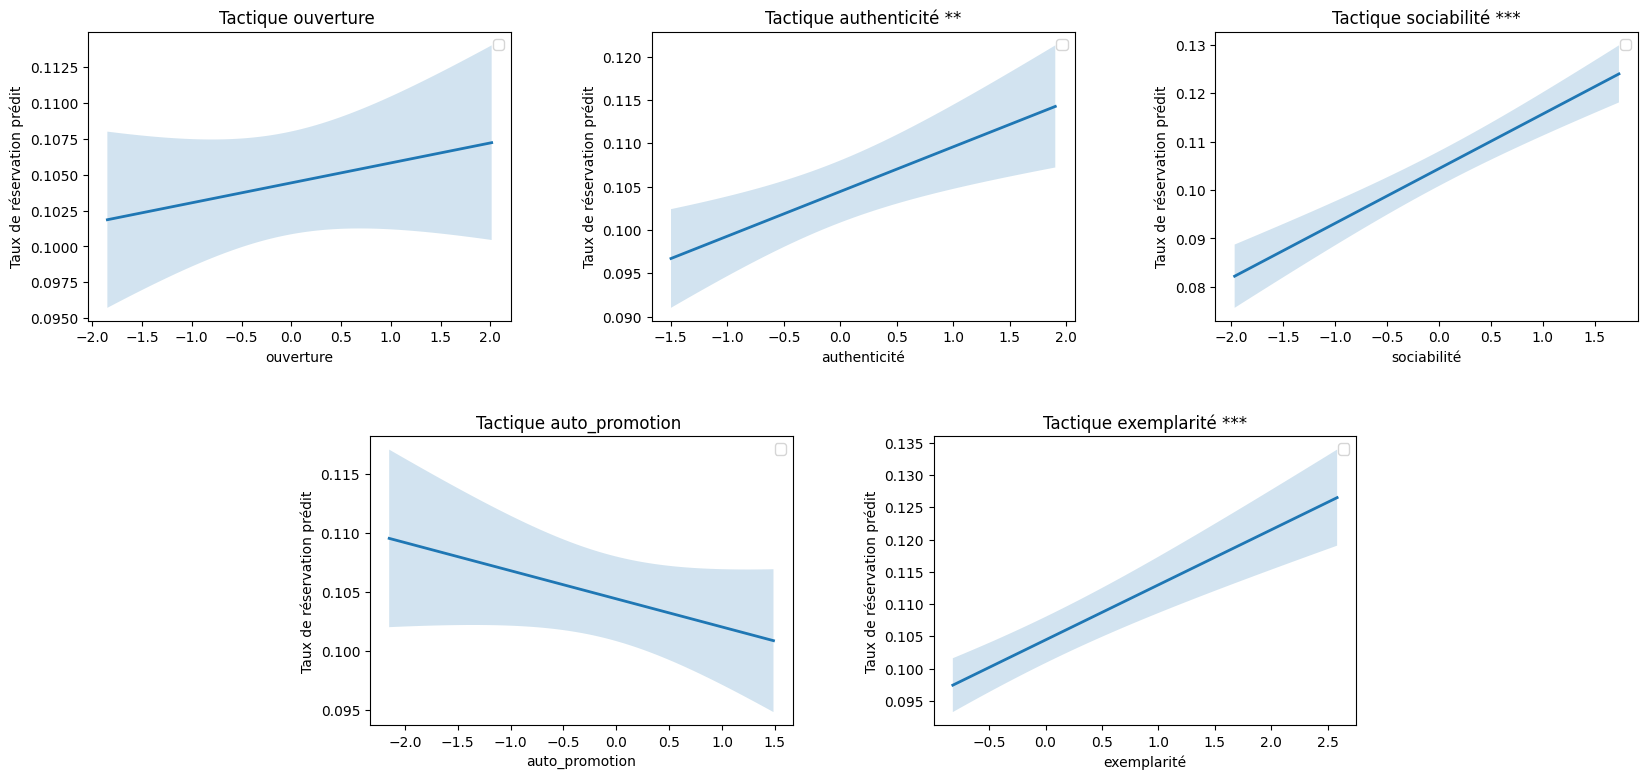

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + sp_changed + len + price + availability_90+ status_changed * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + sp_changed + len + price + availability_90+ status_changed * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + sp_changed + len + price + a

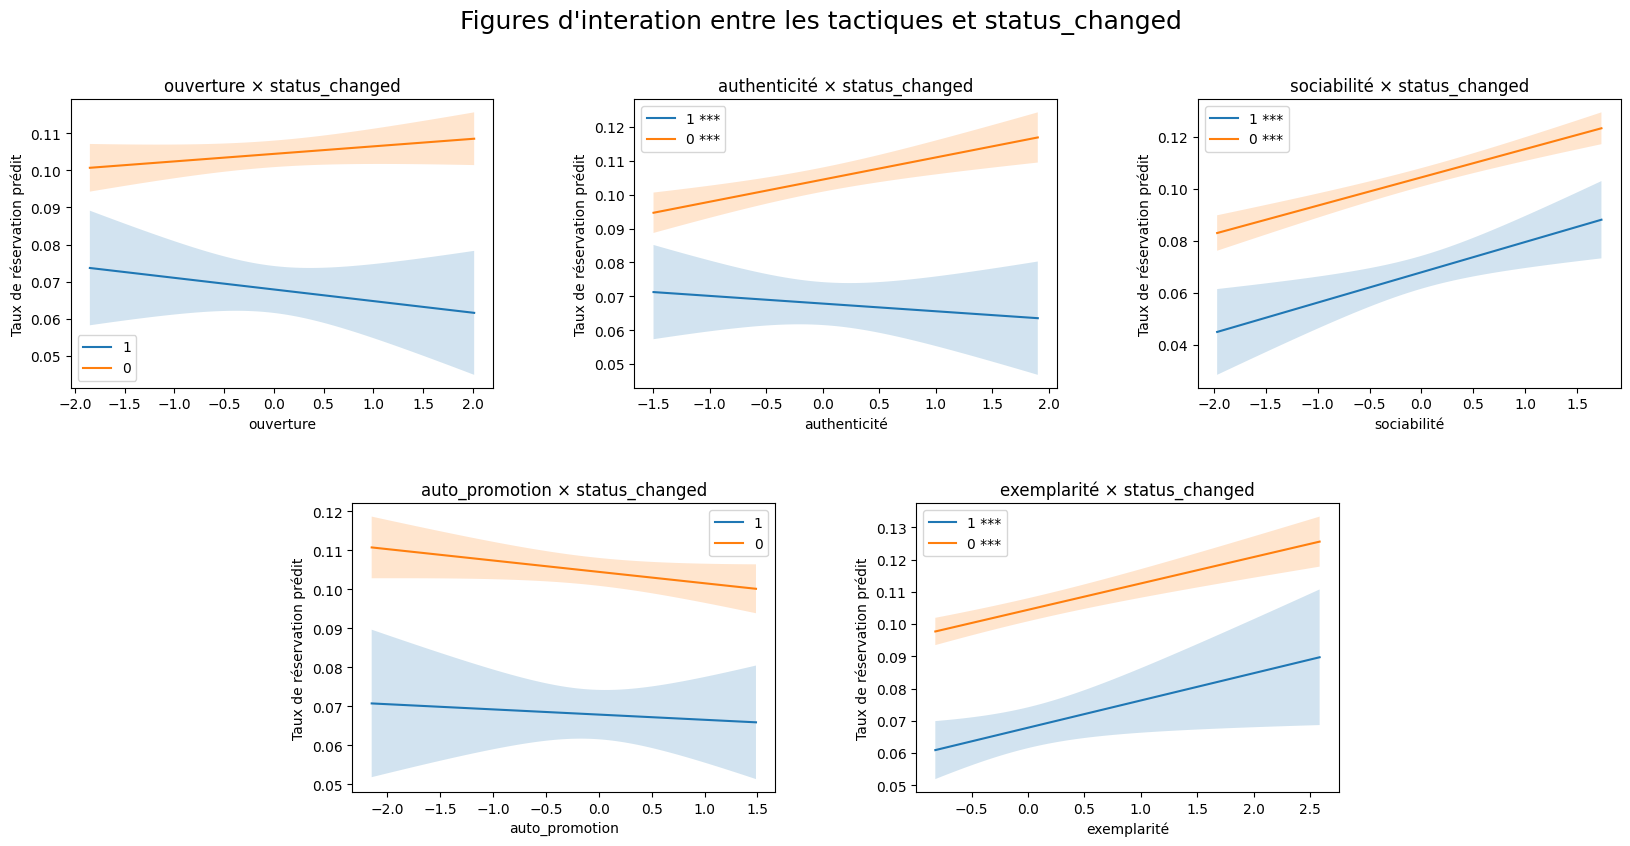

In [45]:

modeling_main(df_input=df_london, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col='status_changed',
            output_folder=OUTPUT_FOLDER_MOD,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

### all

In [ ]:
importlib.reload(modeling)
from utils.modeling import modeling_main, get_booking_rate_l30d
#-------------------------------vars------------------------------------
x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',
    # "is_changed",
    "city",
    "lang", "len",
    "price", 
    "availability_90","room_type", "instant_bookable", #'is_within_1km',#"city"
]  
tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]


In [ ]:

importlib.reload(modeling)
from utils.modeling import modeling_main, get_booking_rate_l30d
x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',
    # "is_changed",
    # "city",
    "lang", "len",
    "price", 
    "availability_90","room_type", "instant_bookable", #'is_within_1km',#"city"
]  
tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]

modeling_main(df_input=df_paris, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col=None,#==jo
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )


=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:12, x_vars_ctrl:12
[CHECK] isna False in all 13 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  lang   len    price  availability_90  room_type  instant_bookable  booking_rate_l90d
False                   False                 False                 False             False              False              False  False  False  False            False      False             False                62738
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_

TypeError: 'in <string>' requires string as left operand, not NoneType

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:13, x_vars_ctrl:13
[CHECK] isna False in all 14 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  city   lang   len    price  availability_90  room_type  instant_bookable  booking_rate_l90d
False                   False                 False                 False             False              False              False  False  False  False  False            False      False             False                112594
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(

,is_base,coef,se,t,pval,sig
paris,False,-0.004015,0.001293,-3.105662,0.001899,**
london,True,0.001124,0.001259,0.892621,0.372062,


authenticité
x paris/london


,is_base,coef,se,t,pval,sig
paris,False,0.000879,0.00143,0.614509,0.53888,
london,True,0.006671,0.001388,4.805927,0.000002,***


sociabilité
x paris/london


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


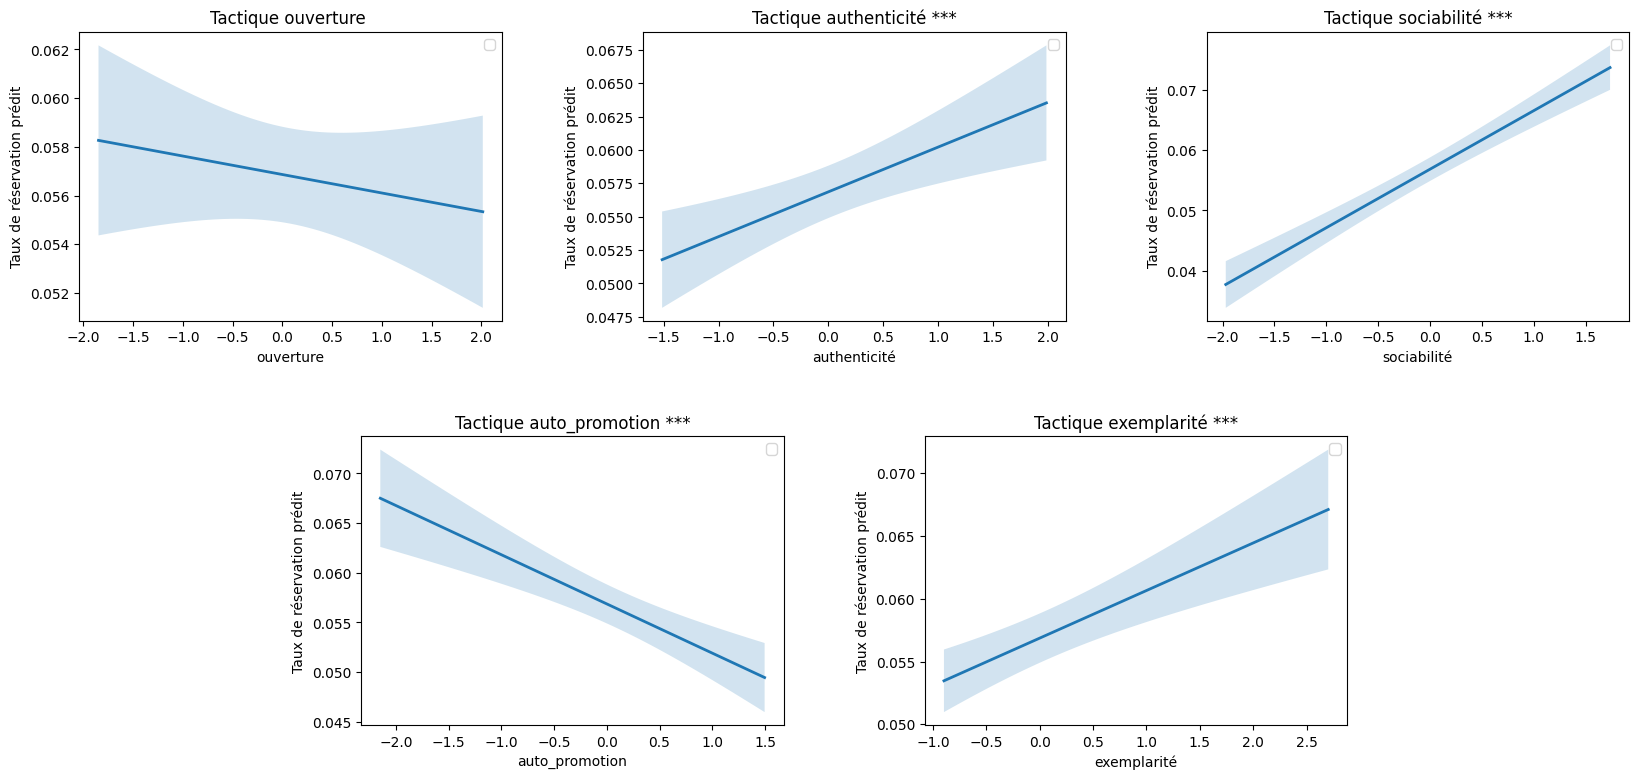

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ C(city) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ C(city) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host +

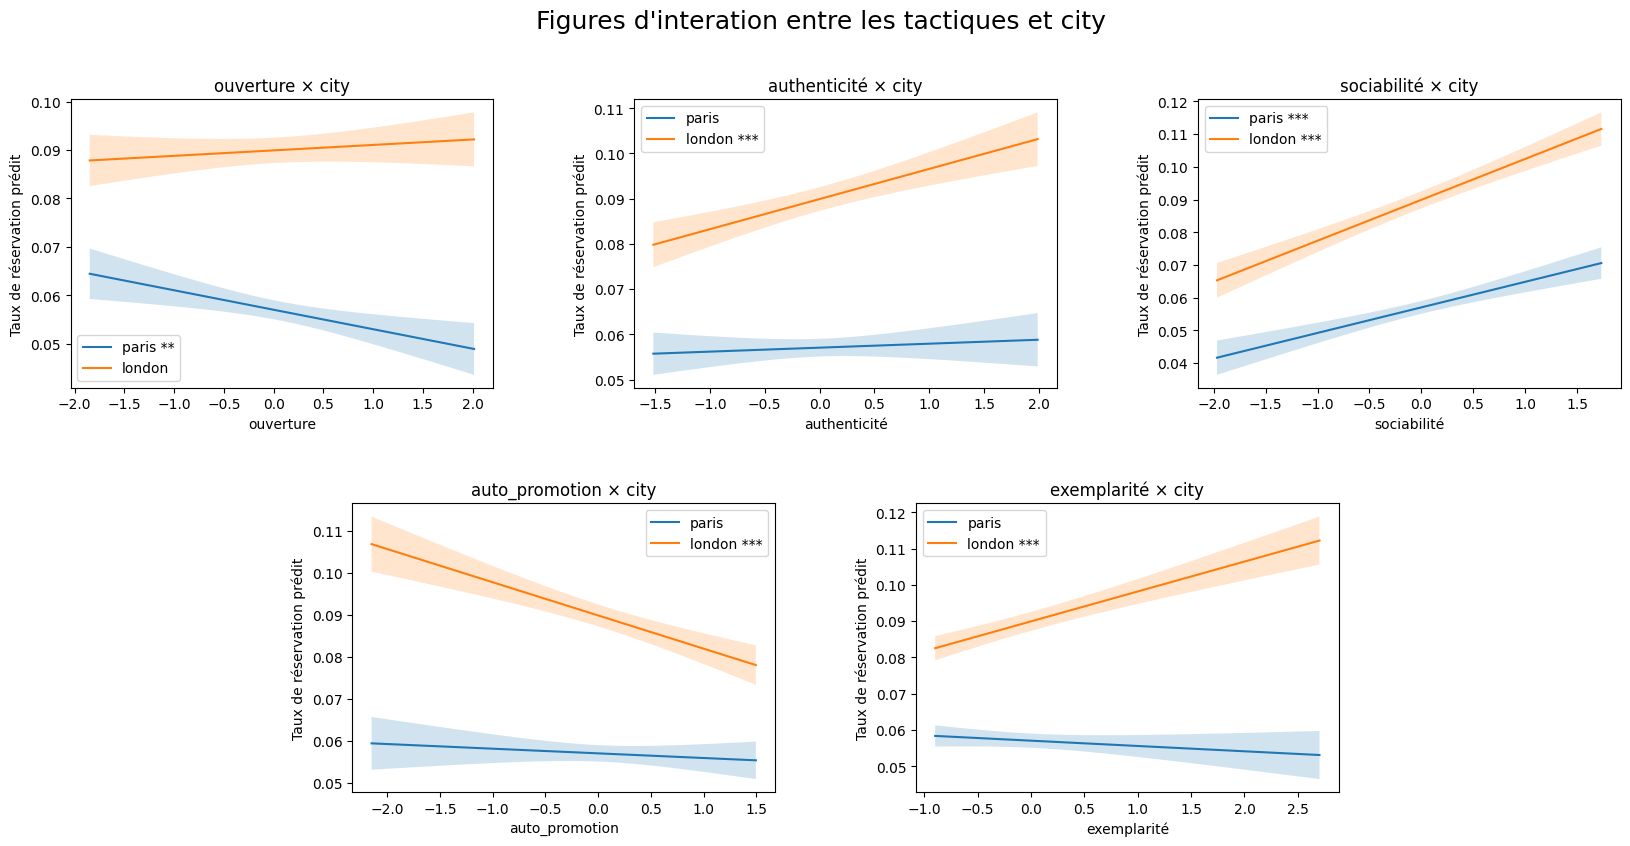

In [ ]:

modeling_main(df_input=df_all, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col='city',#==jo
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:14, x_vars_ctrl:14
[CHECK] isna False in all 15 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  status_changed  city   lang   len    price  availability_90  room_type  instant_bookable  booking_rate_l90d
False                   False                 False                 False             False              False              False           False  False  False  False  False            False      False             False                112594
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_

,is_base,coef,se,t,pval,sig
paris,False,-0.004149,0.001288,-3.220586,0.00128,**
london,True,0.001163,0.001255,0.927151,0.35385,


authenticité
x paris/london


,is_base,coef,se,t,pval,sig
paris,False,0.001428,0.001425,1.001608,0.316535,
london,True,0.00653,0.001383,4.721968,0.000002,***


sociabilité
x paris/london


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


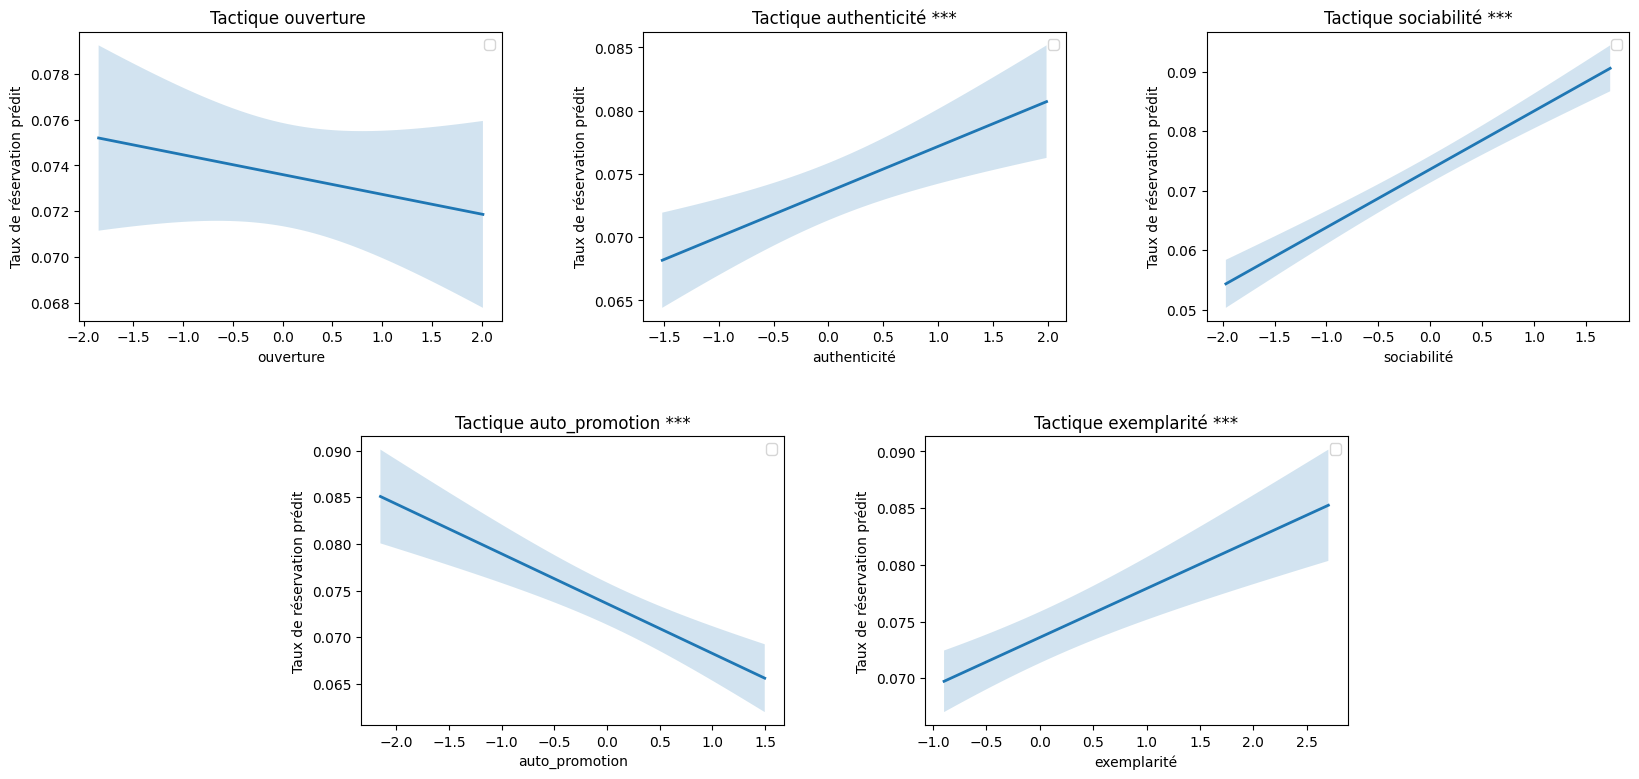

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ C(city) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ C(city) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + year

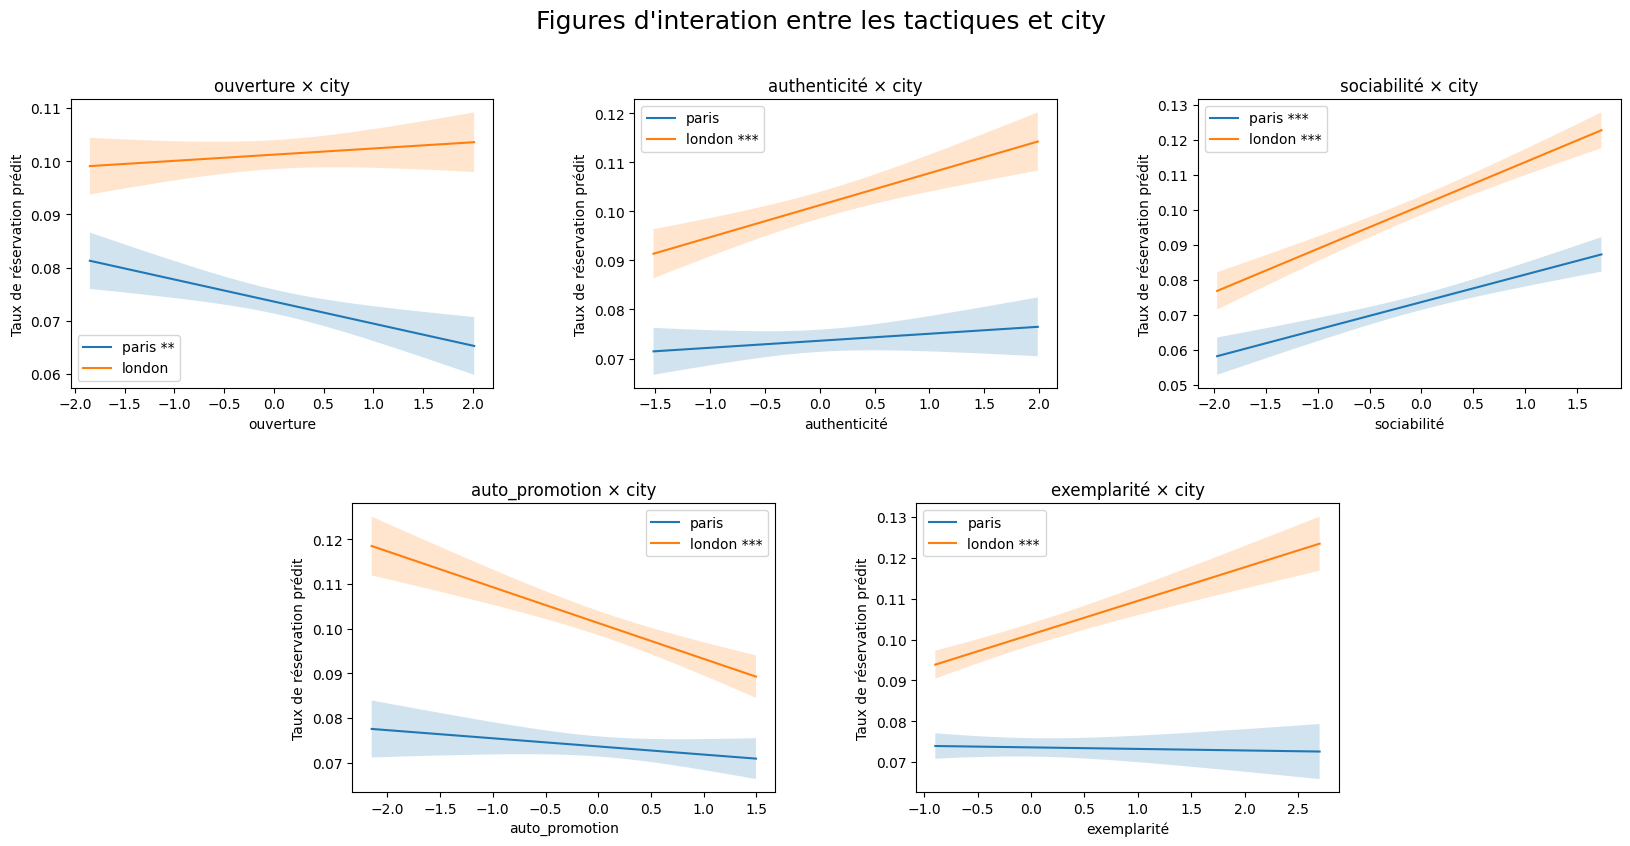

In [12]:
x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    'status_changed', 
    #'old_host_sp_changed',
    # "is_changed",
    "city",
    "lang", "len",
    "price", 
    "availability_90","room_type", "instant_bookable", #'is_within_1km',#"city"
]  

modeling_main(df_input=df_all, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col='city',#==jo
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

In [19]:
# modeling_main(df_input=df_all, 
#             x_vars=x_vars, 
#             y_var="booking_rate_l90d", 
#             key_vars=tactics_vars, 
#             group_col=["city","status_changed"],#'city',#==jo
#             output_folder=None,
#             to_fillna0=True,
#             run_vif=False,
#             # save_models_summary=False,  
#             save_models_table=False,
#             save_plots=False,
#             ndigits=4
#         )
# # 三重交互 city*tactics*status_changed均不显著

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:14, x_vars_ctrl:14
[CHECK] isna False in all 15 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  status_changed  city   lang   len    price  availability_90  room_type  instant_bookable  booking_rate_l90d
False                   False                 False                 False             False              False              False           False  False  False  False  False            False      False             False                30245
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_p

,is_base,coef,se,t,pval,sig
paris,False,-0.004175,0.002212,-1.886998,0.05917,
london,True,-0.002654,0.003293,-0.805961,0.420272,


authenticité
x paris/london


,is_base,coef,se,t,pval,sig
paris,False,-0.00134,0.002409,-0.556254,0.578041,
london,True,0.004192,0.003532,1.186685,0.235361,


sociabilité
x paris/london


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


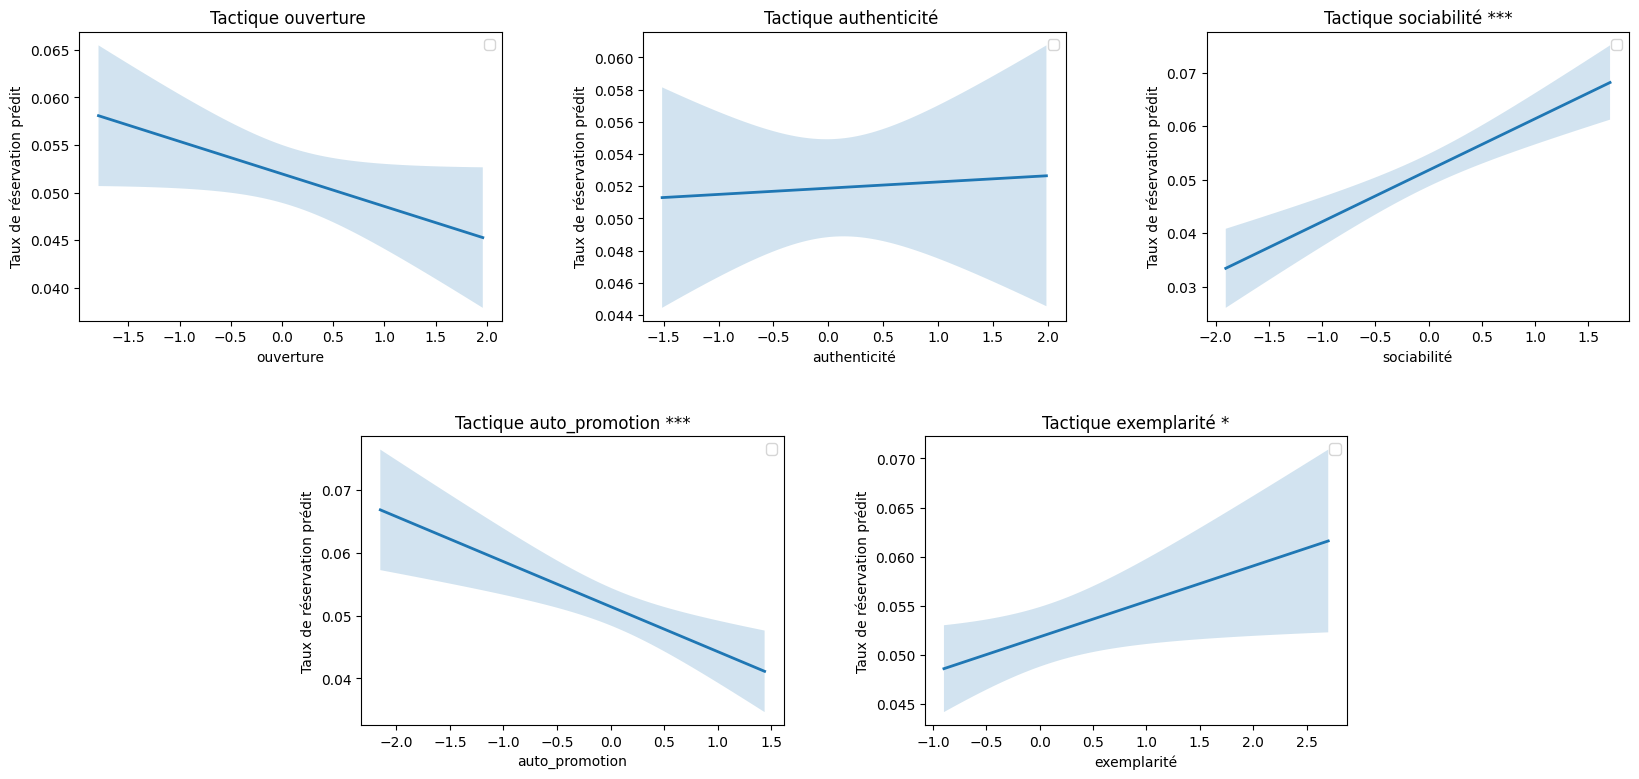

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ C(city) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ C(city) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + year

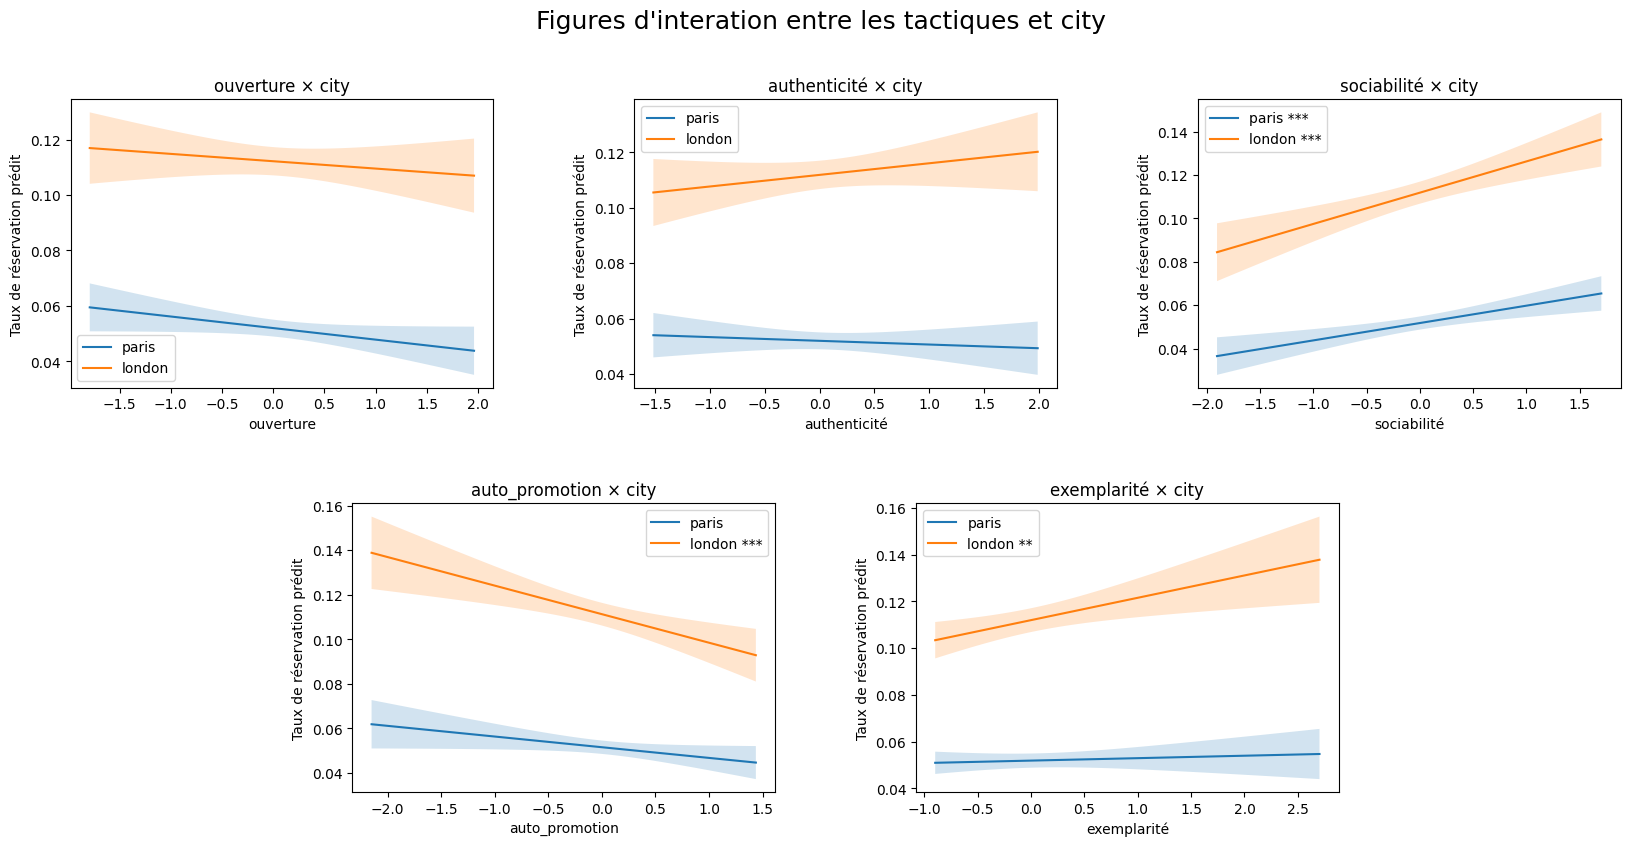

In [13]:
df_all_status_changed=df_all[df_all["status_changed"]==1]
modeling_main(df_input=df_all_status_changed, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col='city',#==jo
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================

 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:14, x_vars_ctrl:14
[CHECK] isna False in all 15 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  status_changed  city   lang   len    price  availability_90  room_type  instant_bookable  booking_rate_l90d
False                   False                 False                 False             False              False              False           False  False  False  False  False            False      False             False                82349
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_p

,is_base,coef,se,t,pval,sig
paris,False,-0.004711,0.00157,-3.000857,0.002693,**
london,True,0.001406,0.00136,1.033758,0.301252,


authenticité
x paris/london


,is_base,coef,se,t,pval,sig
paris,False,0.003767,0.001748,2.154926,0.03117,*
london,True,0.006007,0.001507,3.987101,0.000067,***


sociabilité
x paris/london


...

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(city) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\modeling.py:695: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


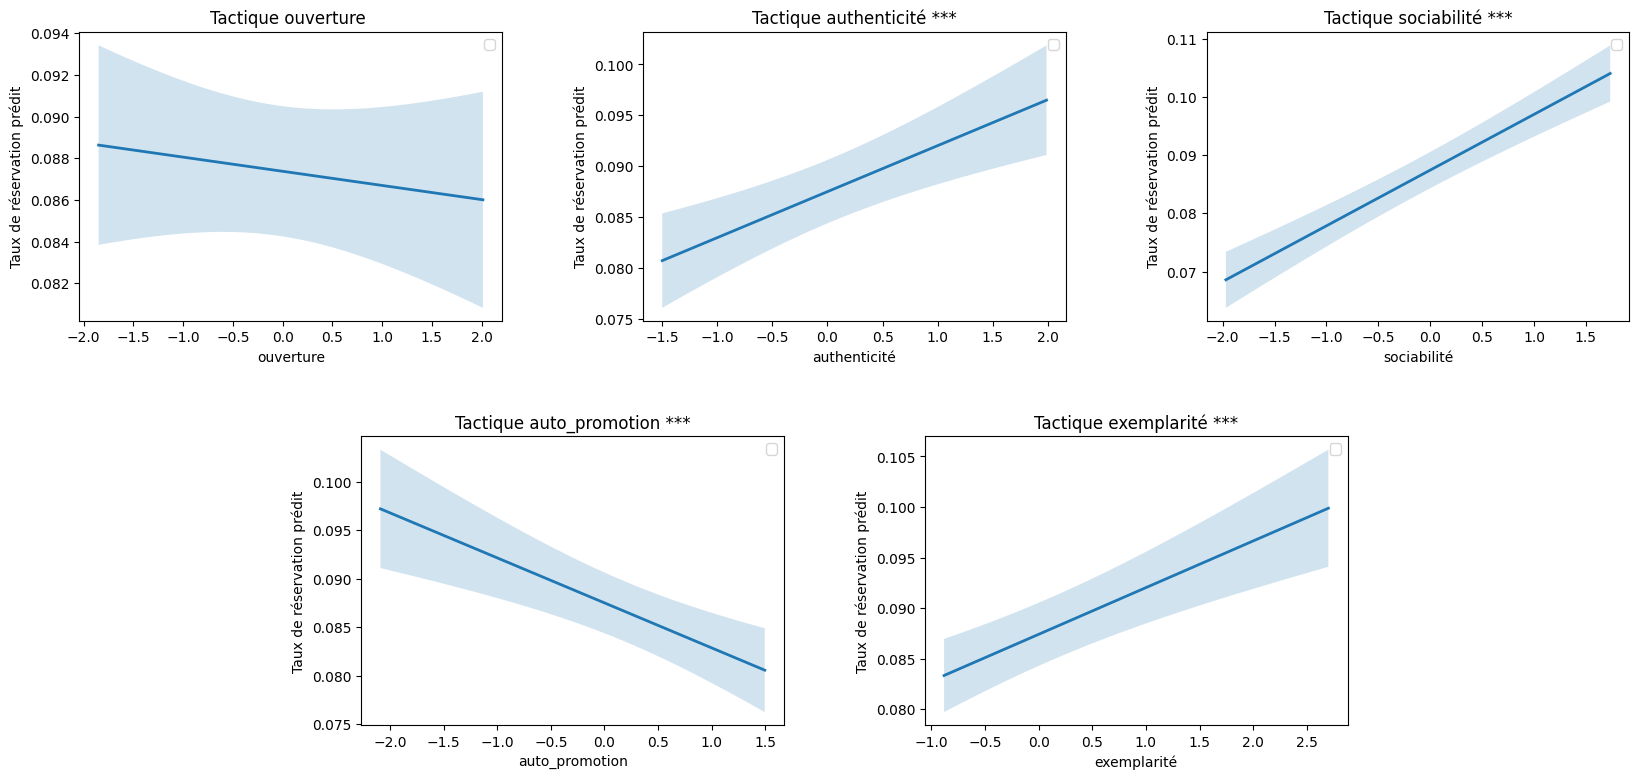

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ C(city) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + status_changed + len + price + availability_90+ C(city) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + year

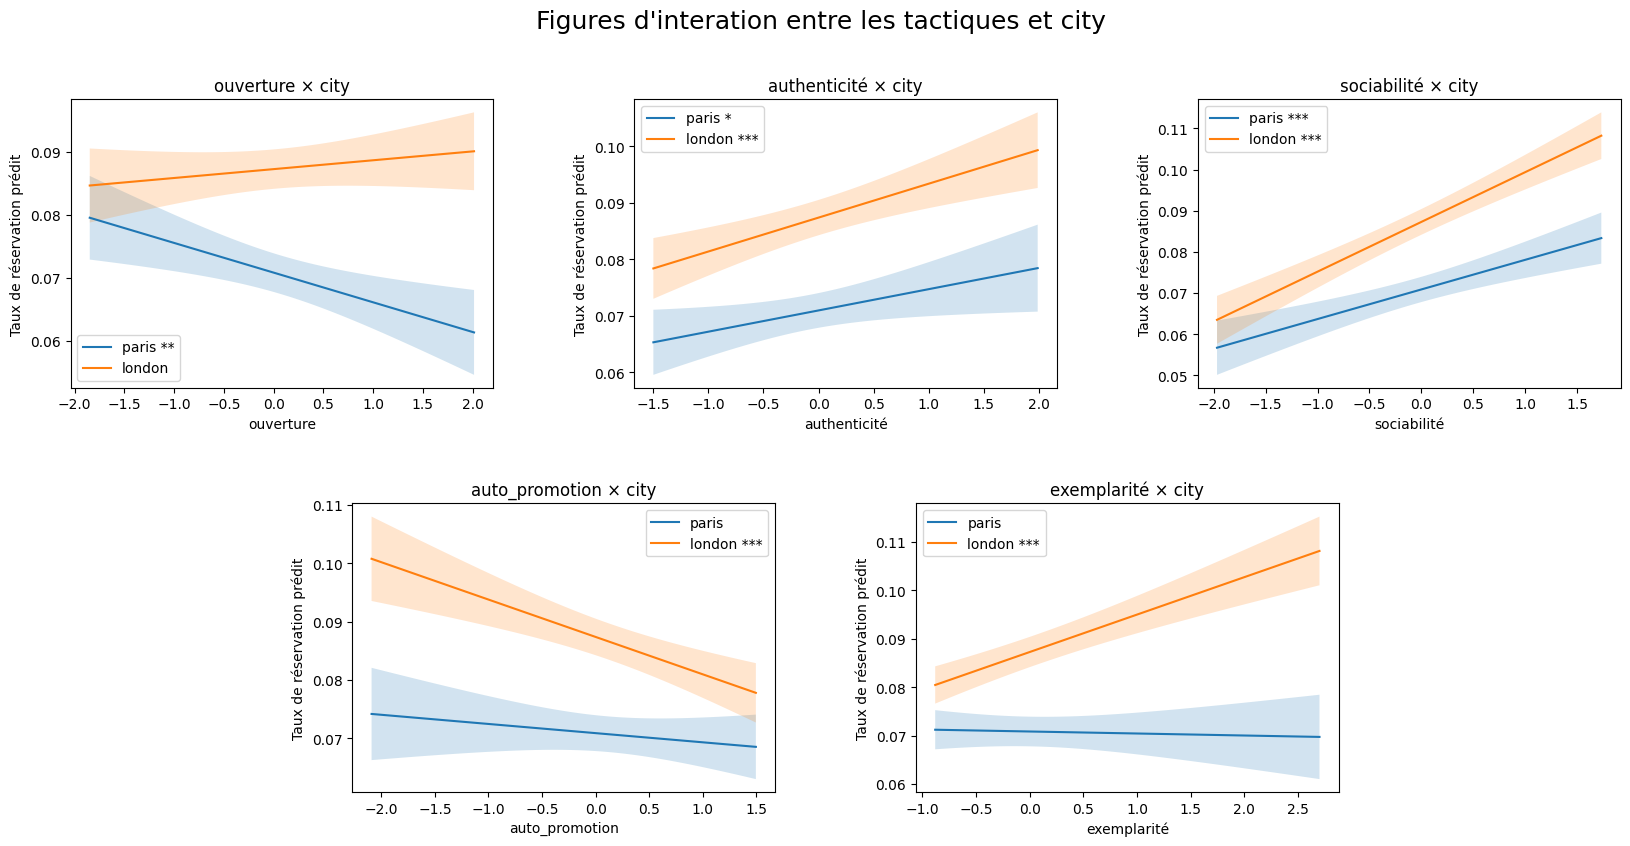

In [14]:
df_all_no_changed=df_all[df_all["status_changed"]==0]
modeling_main(df_input=df_all_no_changed, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col='city',#==jo
            output_folder=None,
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )